In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
os.chdir("/lscratch/fgmaion/MTNG-resims/src")
import utils

In [25]:
# catalog name
catalog = '/scratch/fgmaion/CAMELS/LH_0/groups_090.hdf5'

# value of the scale factor
scale_factor = 1.0

# open the catalogue
f = h5py.File(catalog, 'r')

boxsize = f['Header'].attrs['BoxSize']/1e3
hfac = f['Header'].attrs['HubbleParam']
print(f.keys())
print(f['Parameters'].attrs['Omega0'])
print(f['Parameters'].attrs['WindEnergyIn1e51erg'])
print(f['Parameters'].attrs['VariableWindVelFactor'])
print(f['Parameters'].attrs['RadioFeedbackFactor'])
print(f['Parameters'].attrs['RadioFeedbackReiorientationFactor'])

# read the positions, velocities and masses of the FoF halos
pos_h  = f['Group/GroupPos'][:]/1e3           #positions in Mpc/h
vel_h  = f['Group/GroupVel'][:]/scale_factor  #velocities in km/s
mass_h = f['Group/GroupMass'][:]*1e10         #masses in Msun/h

# read the positions, black hole masses and stellar masses of the subhalos/galaxies
pos_g  = f['Subhalo/SubhaloMass'][:]/1e3        #positions in Mpc/h
BH_g   = f['Subhalo/SubhaloBHMass'][:]*1e10     #black-hole masses in Msun/h
M_star = f['Subhalo/SubhaloMassType'][:,4]*1e10 #stellar masses in Msun/h

# close file
f.close()

<KeysViewHDF5 ['Config', 'Group', 'Header', 'IDs', 'Parameters', 'Subhalo']>
0.309
11.20442
4.9469
1.12194
10.6364


In [6]:
GAMA = np.array([
    [6.875, -0.691, 0.176],
    [7.125, -1.084, 0.125],
    [7.375, -1.011, 0.071],
    [7.625, -1.349, 0.092],
    [7.875, -1.287, 0.079],
    [8.125, -1.544, 0.071],
    [8.375, -1.669, 0.045],
    [8.625, -1.688, 0.032],
    [9.125, -1.886, 0.020],
    [9.375, -2.055, 0.014],
    [9.625, -2.142, 0.010],
    [9.875, -2.219, 0.009],
    [10.125, -2.274, 0.009],
    [10.375, -2.292, 0.009],
    [10.625, -2.361, 0.010],
    [10.875, -2.561, 0.013],
    [11.125, -2.922, 0.019],
    [11.375, -3.414, 0.032],
    [11.625, -4.704, 0.138]
])

GAMA_corr = np.zeros((GAMA.shape[0], 4))
GAMA_corr[:,0] = np.log10( 10**GAMA[:,0] / 0.7**2 )
GAMA_corr[:,1] = np.log10( 10**GAMA[:,1] * 0.7**3 )

# Transforming the errors is a bit more involved
xn = 10**GAMA[:,1] * ( 1 - 10**(-GAMA[:,2]) )
xp = 10**GAMA[:,1] * ( 10**(GAMA[:,2]) - 1 )

GAMA_corr[:,2] = GAMA[:,1] - np.log10( 10**GAMA[:,1] - xn  )
GAMA_corr[:,3] = np.log10( 10**GAMA[:,1] + xp  ) - GAMA[:,1]

In [38]:
smf = {}
index = ['n2', 'n1', '0', '1', '2']

smf['gal_wind'] = {}
smf['rad_fb'] = {}
smf['wind_vel'] = {}
smf['reor_fac'] = {}
for i in range(5):
    smf['gal_wind'][index[i]] = utils.camels_stellar_mf(index[i], 3, nbins=20)
    smf['rad_fb'][index[i]] = utils.camels_stellar_mf(index[i], 4, nbins=20)
    smf['wind_vel'][index[i]] = utils.camels_stellar_mf(index[i], 5, nbins=20)
    smf['reor_fac'][index[i]] = utils.camels_stellar_mf(index[i], 6, nbins=20)

/lscratch/fgmaion/MTNG-resims/src/utils.py:465: RuntimeWarning: invalid value encountered in divide
  return  {'smf':norm * counts, 'bins':bins, 'mstar':mstar_mean / counts}


/tmp/ipykernel_421920/3753017911.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/3753017911.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/3753017911.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/3753017911.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/3753017911.py:11: RuntimeWarning: divide by zero encountered in log10


Text(0.5, 0, 'Stellar Mass $M_*[M_\\odot]$')

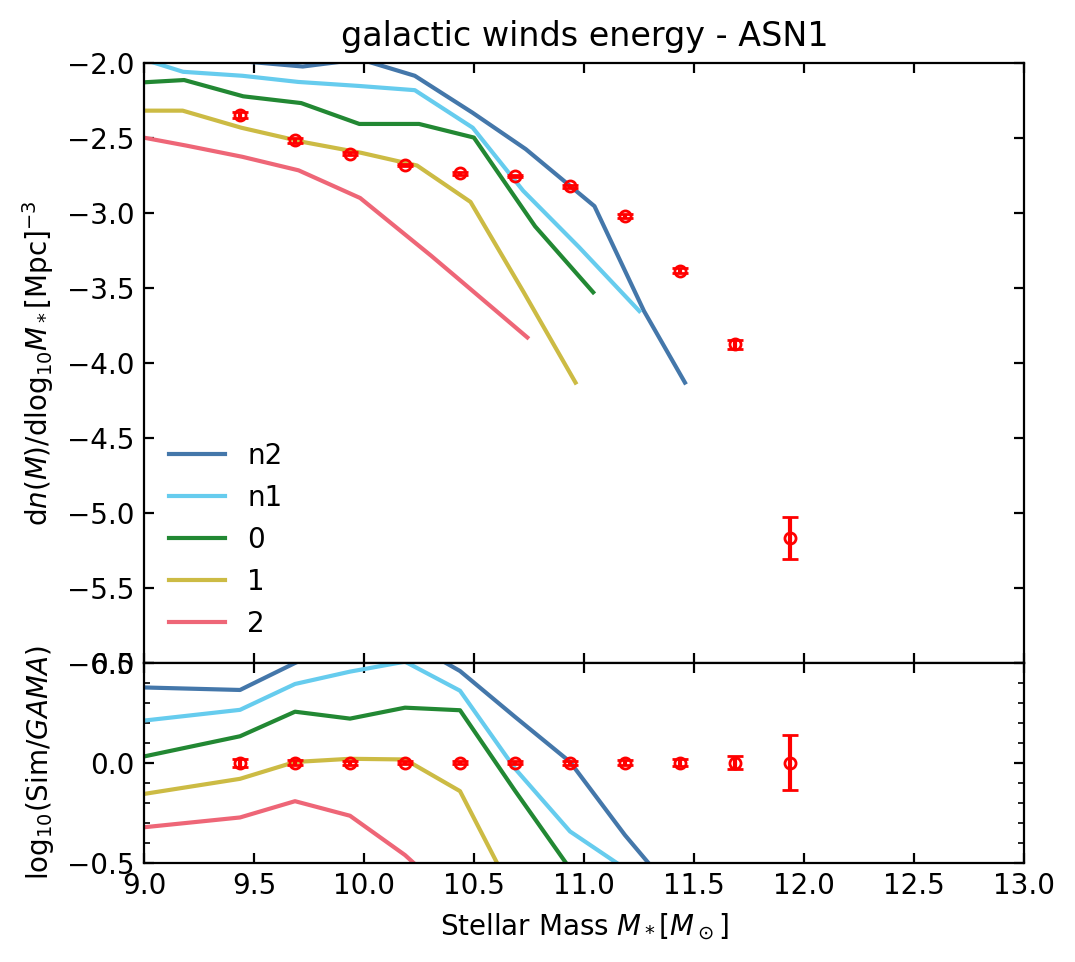

In [42]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_title('galactic winds energy - ASN1')

colors=[ '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']
labels=['n2', 'n1', '0', '1', '2']

for i in range(5):
    ax1.plot(np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf']), color=colors[i], label=labels[i])

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='')

ax1.legend(loc='lower left')

ax1.set_xlim(9, 13) 
ax1.set_ylim(-6, -2) 

ax1.set_ylabel('$\mathrm{d}n(M)/\mathrm{dlog}_{10}M_*[\mathrm{Mpc}]^{-3}$')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

for i in range(5):
    ax2.plot(GAMA_corr[:,0], np.interp( GAMA_corr[:,0], np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf']) )-GAMA_corr[:,1], color=colors[i])

ax2.errorbar(GAMA_corr[:,0], np.zeros(len(GAMA_corr[:,0])), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

ax2.set_xlim(9, 13) 
ax2.set_ylim(-0.5,0.5)

ax2.set_yticks([-0.5,-0.4,-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3,0.4,0.5], minor=True)

ax2.set_ylabel('$\log_{10}(\mathrm{Sim}/GAMA)$')
ax2.set_xlabel('Stellar Mass $M_*[M_\odot]$')


/tmp/ipykernel_421920/3644711732.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['rad_fb'][index[i]]['mstar']), np.log10(smf['rad_fb'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/3644711732.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['rad_fb'][index[i]]['mstar']), np.log10(smf['rad_fb'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/3644711732.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['rad_fb'][index[i]]['mstar']), np.log10(smf['rad_fb'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/3644711732.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['rad_fb'][index[i]]['mstar']), np.log10(smf['rad_fb'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/3644711732.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.lo

Text(0.5, 0, 'Stellar Mass $M_*[M_\\odot]$')

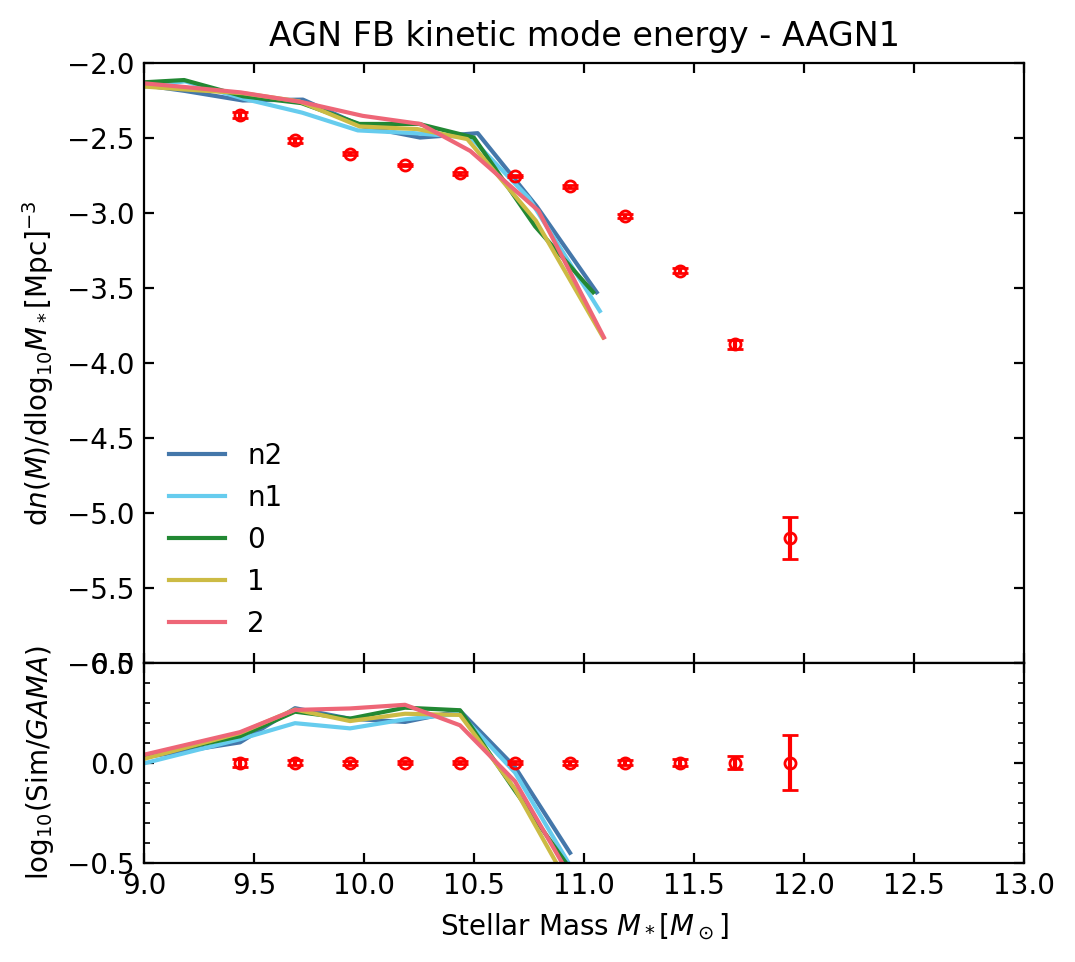

In [44]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_title('AGN FB kinetic mode energy - AAGN1')

colors=[ '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']
labels=['n2', 'n1', '0', '1', '2']

for i in range(5):
    ax1.plot(np.log10(smf['rad_fb'][index[i]]['mstar']), np.log10(smf['rad_fb'][index[i]]['smf']), color=colors[i], label=labels[i])

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='')

ax1.legend(loc='lower left')

ax1.set_xlim(9, 13) 
ax1.set_ylim(-6, -2) 

ax1.set_ylabel('$\mathrm{d}n(M)/\mathrm{dlog}_{10}M_*[\mathrm{Mpc}]^{-3}$')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

for i in range(5):
    ax2.plot(GAMA_corr[:,0], np.interp( GAMA_corr[:,0], np.log10(smf['rad_fb'][index[i]]['mstar']), np.log10(smf['rad_fb'][index[i]]['smf']) )-GAMA_corr[:,1], color=colors[i])

ax2.errorbar(GAMA_corr[:,0], np.zeros(len(GAMA_corr[:,0])), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

ax2.set_xlim(9, 13) 
ax2.set_ylim(-0.5,0.5)

ax2.set_yticks([-0.5,-0.4,-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3,0.4,0.5], minor=True)

ax2.set_ylabel('$\log_{10}(\mathrm{Sim}/GAMA)$')
ax2.set_xlabel('Stellar Mass $M_*[M_\odot]$')


/tmp/ipykernel_421920/1836959399.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['wind_vel'][index[i]]['mstar']), np.log10(smf['wind_vel'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/1836959399.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['wind_vel'][index[i]]['mstar']), np.log10(smf['wind_vel'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/1836959399.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['wind_vel'][index[i]]['mstar']), np.log10(smf['wind_vel'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/1836959399.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['wind_vel'][index[i]]['mstar']), np.log10(smf['wind_vel'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/1836959399.py:11: RuntimeWarning: divide by zero encountered in log10


Text(0.5, 0, 'Stellar Mass $M_*[M_\\odot]$')

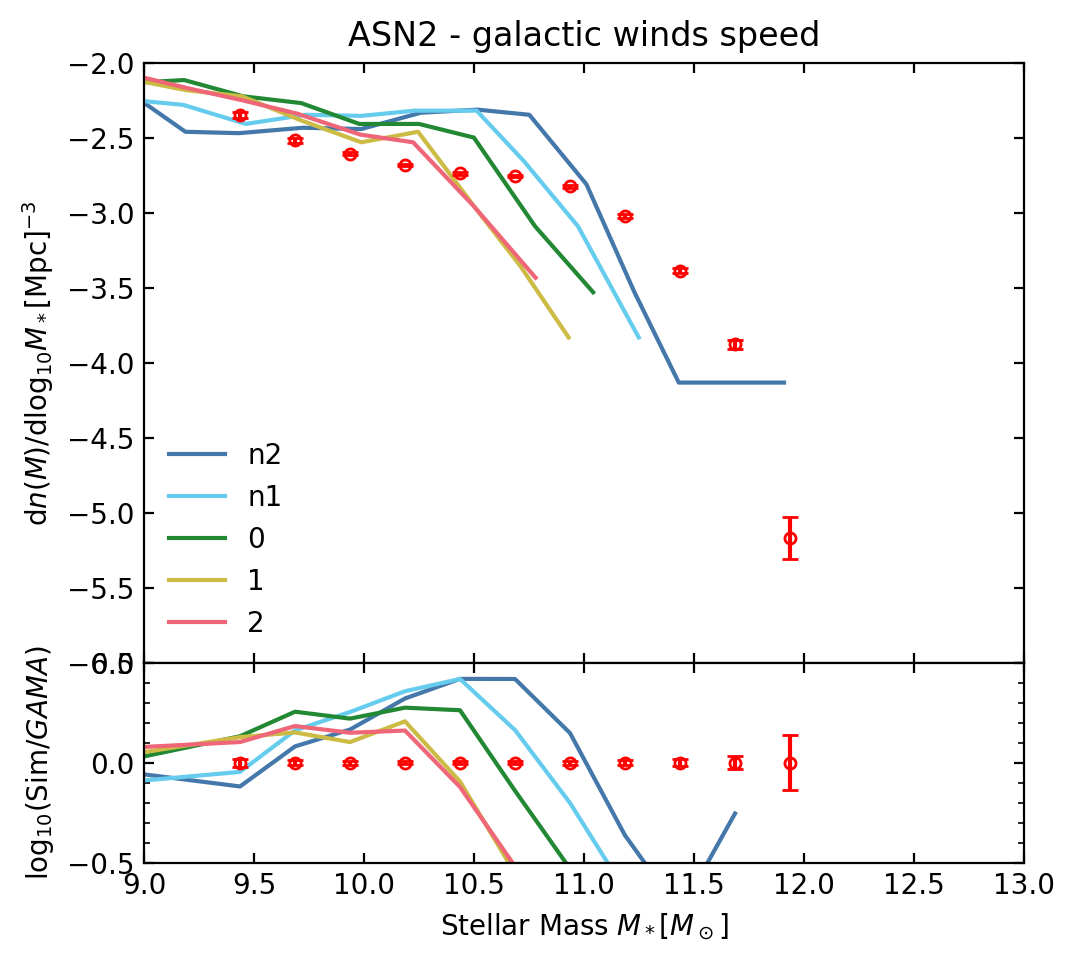

In [45]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_title('ASN2 - galactic winds speed')

colors=[ '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']
labels=['n2', 'n1', '0', '1', '2']

for i in range(5):
    ax1.plot(np.log10(smf['wind_vel'][index[i]]['mstar']), np.log10(smf['wind_vel'][index[i]]['smf']), color=colors[i], label=labels[i])

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='')

ax1.legend(loc='lower left')

ax1.set_xlim(9, 13) 
ax1.set_ylim(-6, -2) 

ax1.set_ylabel('$\mathrm{d}n(M)/\mathrm{dlog}_{10}M_*[\mathrm{Mpc}]^{-3}$')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

for i in range(5):
    ax2.plot(GAMA_corr[:,0], np.interp( GAMA_corr[:,0], np.log10(smf['wind_vel'][index[i]]['mstar']), np.log10(smf['wind_vel'][index[i]]['smf']) )-GAMA_corr[:,1], color=colors[i])

ax2.errorbar(GAMA_corr[:,0], np.zeros(len(GAMA_corr[:,0])), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

ax2.set_xlim(9, 13) 
ax2.set_ylim(-0.5,0.5)

ax2.set_yticks([-0.5,-0.4,-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3,0.4,0.5], minor=True)

ax2.set_ylabel('$\log_{10}(\mathrm{Sim}/GAMA)$')
ax2.set_xlabel('Stellar Mass $M_*[M_\odot]$')


/tmp/ipykernel_421920/3101269204.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['reor_fac'][index[i]]['mstar']), np.log10(smf['reor_fac'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/3101269204.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['reor_fac'][index[i]]['mstar']), np.log10(smf['reor_fac'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/3101269204.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['reor_fac'][index[i]]['mstar']), np.log10(smf['reor_fac'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/3101269204.py:11: RuntimeWarning: divide by zero encountered in log10
  ax1.plot(np.log10(smf['reor_fac'][index[i]]['mstar']), np.log10(smf['reor_fac'][index[i]]['smf']), color=colors[i], label=labels[i])
/tmp/ipykernel_421920/3101269204.py:11: RuntimeWarning: divide by zero encountered in log10


Text(0.5, 0, 'Stellar Mass $M_*[M_\\odot]$')

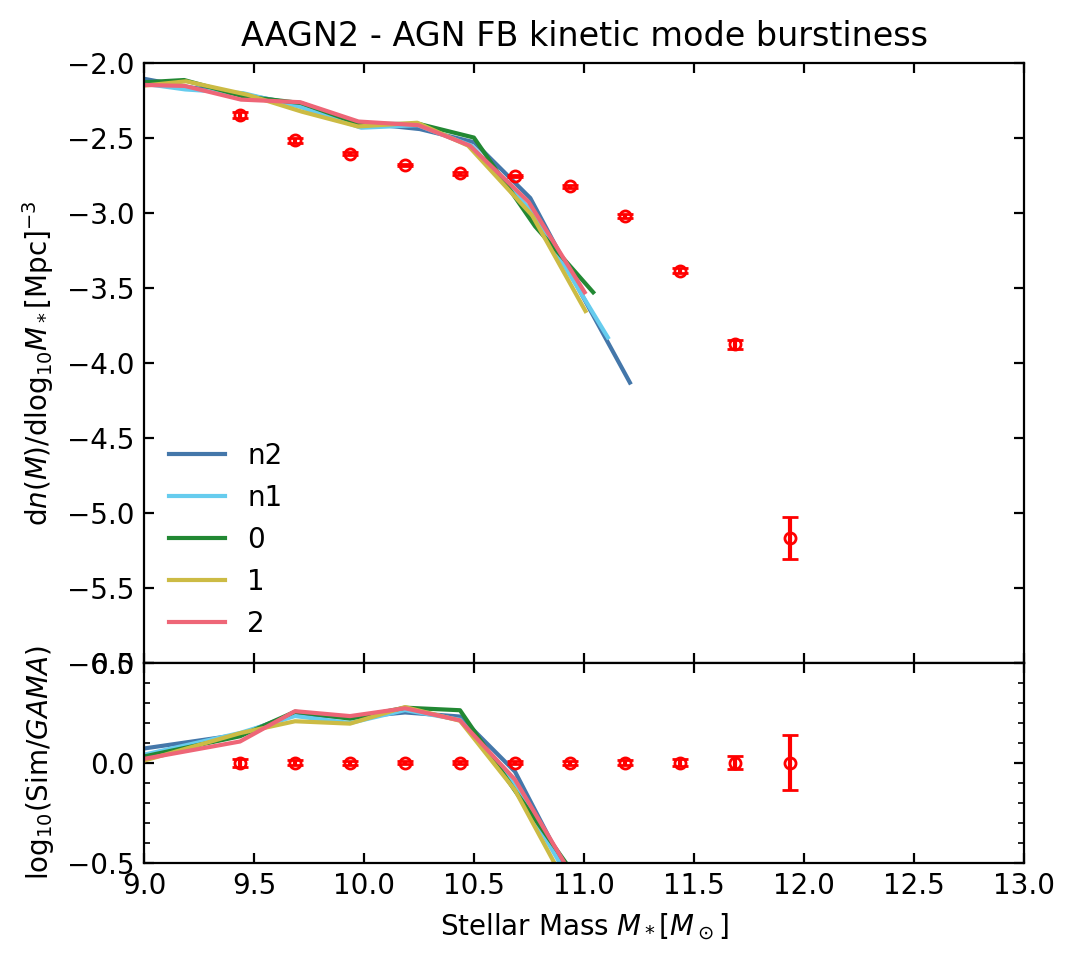

In [46]:
fig = plt.figure(dpi=200, figsize=(5.5,5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_title('AAGN2 - AGN FB kinetic mode burstiness')

colors=[ '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']
labels=['n2', 'n1', '0', '1', '2']

for i in range(5):
    ax1.plot(np.log10(smf['reor_fac'][index[i]]['mstar']), np.log10(smf['reor_fac'][index[i]]['smf']), color=colors[i], label=labels[i])

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='')

ax1.legend(loc='lower left')

ax1.set_xlim(9, 13) 
ax1.set_ylim(-6, -2) 

ax1.set_ylabel('$\mathrm{d}n(M)/\mathrm{dlog}_{10}M_*[\mathrm{Mpc}]^{-3}$')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

for i in range(5):
    ax2.plot(GAMA_corr[:,0], np.interp( GAMA_corr[:,0], np.log10(smf['reor_fac'][index[i]]['mstar']), np.log10(smf['reor_fac'][index[i]]['smf']) )-GAMA_corr[:,1], color=colors[i])

ax2.errorbar(GAMA_corr[:,0], np.zeros(len(GAMA_corr[:,0])), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

ax2.set_xlim(9, 13) 
ax2.set_ylim(-0.5,0.5)

ax2.set_yticks([-0.5,-0.4,-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3,0.4,0.5], minor=True)

ax2.set_ylabel('$\log_{10}(\mathrm{Sim}/GAMA)$')
ax2.set_xlabel('Stellar Mass $M_*[M_\odot]$')


### Make plots for all others

In [ ]:
smf = {}
index = ['n2', 'n1', '0', '1', '2']

for i in range(5):
    smf[index[i]] = utils.camels_stellar_mf(index[i], 3, nbins=20)

fig = plt.figure(dpi=200, figsize=(5.5,5))

ax1=fig.add_axes((.1,.3,.8,.6))

ax1.set_title('galactic winds energy - ASN1')

colors=[ '#4477AA', '#66CCEE', '#228833', '#CCBB44', '#EE6677', '#AA3377', '#BBBBBB']
labels=['n2', 'n1', '0', '1', '2']

for i in range(5):
    ax1.plot(np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf']), color=colors[i], label=labels[i])

ax1.errorbar(GAMA_corr[:,0], GAMA_corr[:,1], yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], color='r', marker='o', capsize=3, ms=4, fillstyle='none', ls='')

ax1.legend(loc='lower left')

ax1.set_xlim(9, 13) 
ax1.set_ylim(-6, -2) 

ax1.set_ylabel('$\mathrm{d}n(M)/\mathrm{dlog}_{10}M_*[\mathrm{Mpc}]^{-3}$')
ax1.set_xticklabels([])

ax2=fig.add_axes((.1,.1,.8,.2))        

for i in range(5):
    ax2.plot(GAMA_corr[:,0], np.interp( GAMA_corr[:,0], np.log10(smf['gal_wind'][index[i]]['mstar']), np.log10(smf['gal_wind'][index[i]]['smf']) )-GAMA_corr[:,1], color=colors[i])

ax2.errorbar(GAMA_corr[:,0], np.zeros(len(GAMA_corr[:,0])), yerr=[GAMA_corr[:,2], GAMA_corr[:,3]], marker='o', color='r', capsize=3, ms=4, fillstyle='none', ls='')

ax2.set_xlim(9, 13) 
ax2.set_ylim(-0.5,0.5)

ax2.set_yticks([-0.5,-0.4,-0.3,-0.2,-0.1,0.0,0.1,0.2,0.3,0.4,0.5], minor=True)

ax2.set_ylabel('$\log_{10}(\mathrm{Sim}/GAMA)$')
ax2.set_xlabel('Stellar Mass $M_*[M_\odot]$')
